# Problema Rainhas

In [ ]:
!pip install deap

In [ ]:
import random
import numpy
from deap import base, creator, tools, algorithms

In [ ]:
# Função objetivo: número de pares de rainhas não-atacadas
# nQueens: Número de rainhas
# Solução ótima: (nQueens x nQueens-1)/2


def fitnessFunction(solucao):
  melhorFitness = (len(solucao) * (len(solucao) - 1)) // 2 # // só a parte inteira
  # Contagem de pares de ataques
  h = 0
  # Verificar os ataques pela diagonal
  for i in range(0, len(solucao)):
    for j in range(i + 1, len(solucao)):
      if abs(i - j) == abs(solucao[i] - solucao[j]): # abs - valor absoluto
        h += 1
      # Verificação de ataques na mesma linha
      if abs(solucao[i] - solucao[j]) == 0:
        h += 1
  return (melhorFitness - h,)

In [ ]:
# Gera o objetivo toolbox responsável por registrar as configurações do framework
toolbox = base.Toolbox()

In [ ]:
# Tamanho do problema
nQueens = 10

In [ ]:
# Cria tipo de função fitness e indivíduo
creator.create("Maximization", base.Fitness, weights=(1.0,))
creator.create("Cromossomo", list, fitness=creator.Maximization)

In [ ]:
# Registra os nomes e os tipos de indivíduo, fitness e população
toolbox.register("atributo", random.randint, 1, nQueens)
toolbox.register("solucaoFinal", tools.initRepeat, creator.Cromossomo, toolbox.atributo, n=nQueens)
toolbox.register("populacao", tools.initRepeat, list, toolbox.solucaoFinal)

In [ ]:
# Registra os operadores. Deve-se manter os nomes evaluate, mate, mutate e select
toolbox.register("evaluate", fitnessFunction)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutUniformInt, low=1, up=nQueens, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)
#toolbox.register("select", tools.selBest)

In [ ]:
# Cadastro de parâmetros e estatísticas
pop = toolbox.populacao(n=50)
prob_cx = 0.8
prob_mt = 0.2
nger = 500

# Estatística
st=tools.Statistics(key = lambda ind: ind.fitness.values)
st.register("avg", numpy.mean)
st.register("std", numpy.std)
st.register("min", numpy.min)
st.register("max", numpy.max)

In [ ]:
from typing_extensions import final
# Execução do Algoritmo
finalPop, log = algorithms.eaSimple(pop, toolbox, prob_cx, prob_mt, nger, st, verbose=True)

melhorSolucao = tools.selBest(finalPop, k=1)
print(f'Optimal Solution: {(nQueens* (nQueens-1))//2}')
print(f'Melhor Fitness: {melhorSolucao[0].fitness.values[0]}')
print(f'Melhor Solucao: {melhorSolucao[0]}')

gen	nevals	avg  	std    	min	max
0  	50    	34.52	2.42685	28 	38 
1  	47    	35.74	2.01802	30 	40 
2  	41    	36.46	2.10912	32 	40 
3  	38    	37.62	1.97879	31 	41 
4  	42    	38.4 	1.86548	33 	41 
5  	40    	38.92	2.05757	32 	42 
6  	41    	38.84	1.64146	35 	41 
7  	43    	39.96	1.24836	36 	42 
8  	44    	40.6 	0.87178	38 	42 
9  	41    	40.86	1.13155	34 	42 
10 	46    	41.1 	1.08167	36 	42 
11 	43    	41.5 	0.921954	38 	42 
12 	34    	41.8 	0.663325	39 	42 
13 	46    	41.6 	1.0583  	37 	42 
14 	40    	41.78	0.756042	38 	42 
15 	46    	41.64	0.932952	38 	42 
16 	43    	41.78	0.701142	39 	42 
17 	41    	41.66	0.971802	37 	42 
18 	39    	41.7 	0.8544  	39 	42 
19 	39    	41.8 	0.748331	38 	42 
20 	46    	41.94	0.310483	40 	42 
21 	44    	41.9 	0.458258	39 	42 
22 	43    	41.74	0.715821	39 	42 
23 	39    	41.64	1.07257 	37 	42 
24 	41    	41.78	0.807217	37 	42 
25 	43    	41.86	0.748599	37 	42 
26 	43    	41.54	1.08093 	38 	42 
27 	32    	42   	0       	42 	42 
28 	45    	41.72	1.0008  	

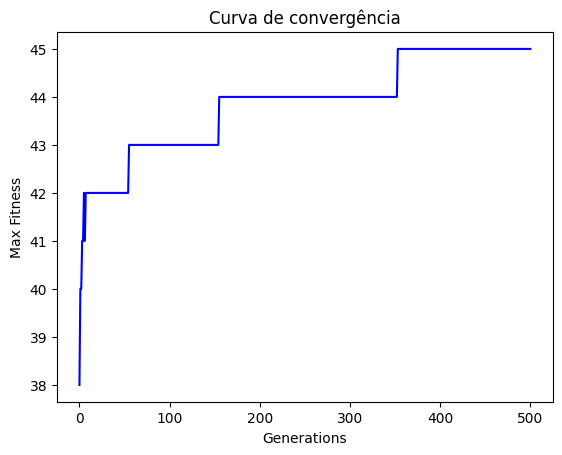

In [ ]:
# Curva de convergência

import matplotlib.pyplot as plt

# Estrair estatística
maxFit = log.select("max")

# Plotar estatística
plt.plot(maxFit, color='blue')
plt.xlabel('Generations')
plt.ylabel('Max Fitness')
plt.title('Curva de convergência')
plt.show()

In [ ]:
# Cadastra algoritmo Mu+Lambda
mu = 40
_lambda = 30
popMu_Lambda = toolbox.populacao(n=mu)
finalPop, log = algorithms.eaMuPlusLambda(popMu_Lambda, toolbox, mu, _lambda, prob_cx, prob_mt, nger, st, verbose=True)

melhorSolucao = tools.selBest(finalPop, k=1)
print(f'Optimal Solution: {(nQueens* (nQueens-1))//2}')
print(f'Solucao: {melhorSolucao[0]}- Fitness  {melhorSolucao[0].fitness.values[0]}')



gen	nevals	avg   	std    	min	max
0  	40    	34.475	3.21704	27 	40 
1  	30    	36.25 	1.82688	33 	40 
2  	30    	38    	1.36015	34 	40 
3  	30    	39.05 	0.893029	37 	42 
4  	30    	39.775	0.821203	38 	42 
5  	30    	40.35 	0.93675 	39 	42 
6  	30    	41.025	0.961444	40 	42 
7  	30    	41.55 	0.772981	40 	42 
8  	30    	42    	0       	42 	42 
9  	30    	42    	0       	42 	42 
10 	30    	42    	0       	42 	42 
11 	30    	42    	0       	42 	42 
12 	30    	42    	0       	42 	42 
13 	30    	42    	0       	42 	42 
14 	30    	42    	0       	42 	42 
15 	30    	42    	0       	42 	42 
16 	30    	42    	0       	42 	42 
17 	30    	42.075	0.263391	42 	43 
18 	30    	42.15 	0.357071	42 	43 
19 	30    	42.375	0.484123	42 	43 
20 	30    	42.65 	0.47697 	42 	43 
21 	30    	42.975	0.156125	42 	43 
22 	30    	43    	0       	43 	43 
23 	30    	43    	0       	43 	43 
24 	30    	43    	0       	43 	43 
25 	30    	43    	0       	43 	43 
26 	30    	43    	0       	43 	43 
27 	30    	43    	0     

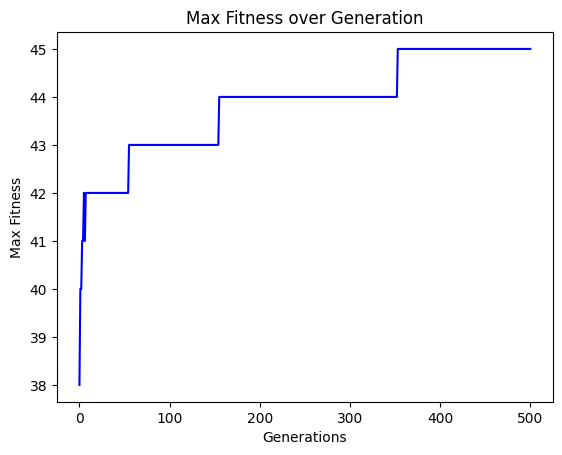

In [ ]:
# Estrair estatística
maxFitnessValues = log.select("max")

# Plotar estatística
plt.plot(maxFit, color='blue')
plt.xlabel('Generations')
plt.ylabel('Max Fitness')
plt.title('Max Fitness over Generation')
plt.show()